In [1]:
import sys
sys.path.append("..")
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


==========================================================
#### STEP 1: EXPLORATORY DATA ANALYSIS (EDA)
#### YouTube Comments Sentiment Dataset
==========================================================

 ------------------------------------------------------------------
 1. Load data
 ------------------------------------------------------------------

In [2]:
import pandas as pd
df = pd.read_csv("../data/comments.csv")
print("Shape:", df.shape)


Shape: (103482, 12)


 ------------------------------------------------------------------
 2. Basic info / missing values / duplicates
 ------------------------------------------------------------------

In [3]:
print(df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate comment texts:", df["CommentText"].duplicated().sum())

CommentID          object
VideoID            object
VideoTitle         object
AuthorName         object
AuthorChannelID    object
CommentText        object
Sentiment          object
Likes               int64
Replies             int64
PublishedAt        object
CountryCode        object
CategoryID          int64
dtype: object

Missing values:
 CommentID           0
VideoID             0
VideoTitle          0
AuthorName         71
AuthorChannelID     0
CommentText         0
Sentiment           0
Likes               0
Replies             0
PublishedAt         0
CountryCode         0
CategoryID          0
dtype: int64

Duplicate rows: 0
Duplicate comment texts: 2152


 ------------------------------------------------------------------
 3. Target variable distribution (Sentiment)
 ------------------------------------------------------------------

In [4]:
print(df["Sentiment"].value_counts())
print(df["Sentiment"].value_counts(normalize=True))

Sentiment
Negative    35073
Positive    34308
Neutral     34101
Name: count, dtype: int64
Sentiment
Negative    0.338929
Positive    0.331536
Neutral     0.329536
Name: proportion, dtype: float64


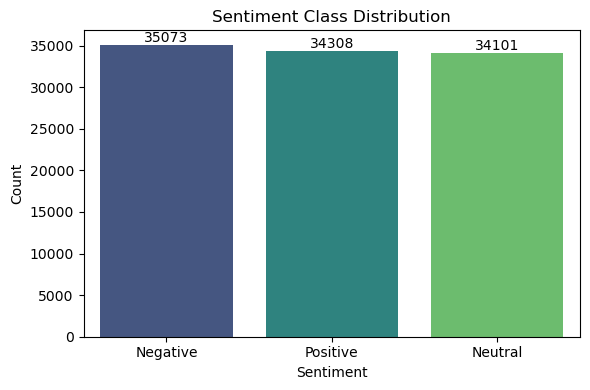

In [11]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index,
    palette="viridis"
)

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()